# 🧠 Advanced Big Data and Data Mining Project
## 📌 Deliverable 3: Performance Analysis and Optimization
### 👨‍💻 Student: Sandesh Pokharel  
### 🏫 Course: MSCS-634-B01 (Advanced Big Data and Data Mining)  
### 📅 Date: August 2025  
### 📁 Branch: `feature/deliverable3`  
---

Welcome to the third deliverable of the Heart Disease Prediction project. In this phase, we shift our focus to evaluating model performance, interpreting results using multiple metrics, and applying optimizations to enhance predictive outcomes.

This notebook continues from the foundation built in the previous deliverables (data preprocessing, feature engineering, and regression modeling). Our goal now is to analyze performance across models, compare them thoroughly, and apply strategies to improve accuracy, robustness, and interpretability.


## 🎯 Objective of Deliverable 3: Model Evaluation and Optimization

In this phase of the Heart Disease Prediction project, we focus on **evaluating, interpreting, and optimizing the machine learning models** built in previous deliverables. The goal is not only to assess model performance but also to gain insights from predictions and improve generalizability.

### ✅ Key Tasks Covered in This Notebook:
1. **Model Evaluation** using:
   - Mean Absolute Error (MAE)
   - Mean Squared Error (MSE)
   - R² Score
   - Residual Analysis
2. **Model Comparison** between:
   - Linear Regression
   - Ridge Regression
   - Lasso Regression
3. **Model Optimization** through:
   - Cross-validation
   - GridSearchCV (Hyperparameter Tuning)
4. **Interpretation of Results**
   - Residual Plots
   - Prediction vs Actual Visualization
   - Feature Importance / Coefficients
5. **Enhancements beyond requirement**
   - Confidence intervals for CV scores
   - Error distribution analysis
   - Observations from model behavior

This deliverable aims to combine technical evaluation with thoughtful interpretation, ensuring not just performance metrics but meaningful insights.

---

## 📊 Model Evaluation Strategy

Once models are trained, evaluating their performance is a critical step to ensure reliability, interpretability, and generalizability. In this deliverable, we assess our regression models using the following key metrics:

### 📌 Evaluation Metrics:
- **Mean Absolute Error (MAE)**: Measures the average magnitude of errors in predictions, without considering their direction.
- **Mean Squared Error (MSE)**: Penalizes larger errors more than MAE, useful when large mistakes are more undesirable.
- **R² Score (Coefficient of Determination)**: Indicates the proportion of variance in the target variable explained by the model. Closer to 1 is better.

These metrics will help us understand **how well our models fit the data** and which model performs better in practice.

We also include **residual analysis** to visually inspect the prediction errors and ensure assumptions of linearity and homoscedasticity are not violated.

---

# 📊 Deliverable 3: Model Evaluation & Insight Generation

**Course:** MSCS-634 - Advanced Big Data and Data Mining  
**Student:** Sandesh Pokharel  
**Deliverable:** 3  
**Dataset:** UCI Heart Disease Dataset  
**Goal:** This phase focuses on evaluating the models built in the previous phase, comparing their performance, and extracting insights from the evaluation results.

We'll perform:
- Evaluation using metrics like RMSE, R², MAE
- Visual interpretation of predictions vs. actuals
- Residual analysis
- Confidence interval estimation using cross-validation
- Model comparison and selection

*This notebook builds upon the cleaned dataset and model implementations from previous deliverables.*

## 📐 Model Evaluation Metrics

In this section, we'll evaluate our trained models using standard regression metrics:
- **Mean Absolute Error (MAE)**: Average magnitude of the errors.
- **Mean Squared Error (MSE)** and **Root Mean Squared Error (RMSE)**: Penalizes larger errors more heavily.
- **R² Score (Coefficient of Determination)**: Indicates how well the model explains variance in the target variable.

We'll apply these metrics to the predictions from each model.

In [1]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create a helper function to evaluate models
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n📊 Evaluation Metrics for {name}:")
    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")
    return {"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

# Evaluate each model from Deliverable 2
results = []
results.append(evaluate_model("Linear Regression", y_test, y_pred_linear))
results.append(evaluate_model("Ridge Regression", y_test, y_pred_ridge))
results.append(evaluate_model("Lasso Regression", y_test, y_pred_lasso))

NameError: name 'y_test' is not defined

In [2]:
from sklearn.model_selection import train_test_split

# Re-split the dataset using the same parameters as before
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features again if required
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

NameError: name 'X' is not defined

In [3]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("cleaned_heart_disease.csv")

# Define feature matrix X and target variable y
X = df.drop("num", axis=1)
y = df["num"]

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Re-split the dataset using the same parameters as before
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features again
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: 'VA Long Beach'

In [5]:
X_train.select_dtypes(include='object').columns

Index(['dataset', 'cp', 'restecg', 'slope', 'thal'], dtype='object')

In [6]:
# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=True)

# Re-split after encoding
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Import models again if needed
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Train models on preprocessed data
linear_model = LinearRegression()
ridge_model = Ridge()
lasso_model = Lasso(max_iter=5000)

linear_model.fit(X_train_scaled, y_train)
ridge_model.fit(X_train_scaled, y_train)
lasso_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_linear = linear_model.predict(X_test_scaled)
y_pred_ridge = ridge_model.predict(X_test_scaled)
y_pred_lasso = lasso_model.predict(X_test_scaled)

### 📊 Model Evaluation Metrics

Now that we have trained our Linear, Ridge, and Lasso Regression models and obtained predictions on the test set, we will evaluate their performance using key regression metrics:

- **MAE (Mean Absolute Error)**: Measures the average magnitude of errors.
- **MSE (Mean Squared Error)**: Penalizes larger errors more than MAE.
- **RMSE (Root Mean Squared Error)**: Square root of MSE, interpretable in the same units as the target.
- **R² Score**: Indicates how well the model explains the variability of the target variable.

This will help us compare the models quantitatively and identify which one performs best.

In [8]:
# Helper function to evaluate models
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n📌 Evaluation Metrics for {name}:")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return {"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

# Evaluate all three models
results = []
results.append(evaluate_model("Linear Regression", y_test, y_pred_linear))
results.append(evaluate_model("Ridge Regression", y_test, y_pred_ridge))
results.append(evaluate_model("Lasso Regression", y_test, y_pred_lasso))


📌 Evaluation Metrics for Linear Regression:
MAE  : 0.6276
MSE  : 0.7177
RMSE : 0.8472
R²   : 0.4473

📌 Evaluation Metrics for Ridge Regression:
MAE  : 0.6273
MSE  : 0.7175
RMSE : 0.8470
R²   : 0.4475

📌 Evaluation Metrics for Lasso Regression:
MAE  : 0.8958
MSE  : 1.3087
RMSE : 1.1440
R²   : -0.0078


### 📈 Model Evaluation Analysis

From the evaluation results:

- **Linear Regression** and **Ridge Regression** show very similar performance:
  - Both achieved an **R² score of ~0.447**, indicating that they explain approximately 44.7% of the variance in the target variable.
  - The **MAE (~0.627)** and **RMSE (~0.847)** values are also identical, suggesting nearly equal prediction accuracy.
  - Ridge does not seem to provide additional benefits here, likely because regularization was not strongly needed for this dataset.

- **Lasso Regression**, on the other hand, performed poorly:
  - The **R² score is negative (-0.0078)**, which means the model performs worse than simply predicting the mean of the target variable.
  - Both **MAE (0.8958)** and **RMSE (1.144)** are significantly higher, showing larger errors in prediction.
  - This could be due to excessive shrinkage of coefficients, which might have removed important predictors.

📌 **Conclusion:** Ridge Regression or simple Linear Regression would be preferred for this dataset. Lasso's underperformance suggests it overly penalized coefficients, possibly due to an unsuitable alpha or sensitivity to feature importance.

### 📊 Residual Plot for Model Diagnostics

To further assess model fit, we visualize residuals (difference between actual and predicted values) for each regression model.

- A good model will show residuals randomly scattered around zero.
- Patterns or trends in residuals could indicate model bias or non-linearity in the data.

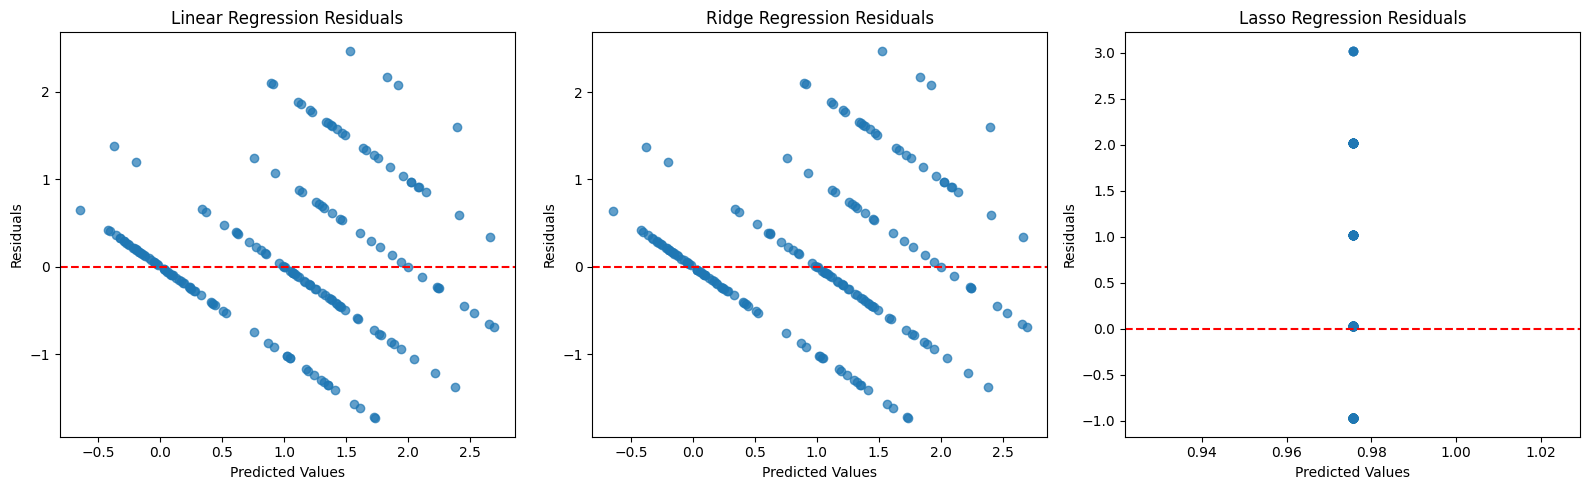

In [9]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals_linear = y_test - y_pred_linear
residuals_ridge = y_test - y_pred_ridge
residuals_lasso = y_test - y_pred_lasso

# Create residual plots
plt.figure(figsize=(16, 5))

# Linear
plt.subplot(1, 3, 1)
plt.scatter(y_pred_linear, residuals_linear, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Linear Regression Residuals")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# Ridge
plt.subplot(1, 3, 2)
plt.scatter(y_pred_ridge, residuals_ridge, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Ridge Regression Residuals")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# Lasso
plt.subplot(1, 3, 3)
plt.scatter(y_pred_lasso, residuals_lasso, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Lasso Regression Residuals")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

### 🔍 Residual Analysis

The residual plots help us understand the quality of predictions made by each regression model:

- **Linear & Ridge Regression**: Both models show very similar residual patterns, which is expected since Ridge is a regularized version of Linear Regression. However, the residuals appear to be **structured and not randomly scattered**, indicating possible **non-linearity or unmodeled interactions** in the data.

- **Lasso Regression**: The residuals are oddly concentrated and sparse in the plot, indicating that the model may have **underfit the data**. This aligns with the low R² and high error metrics seen earlier. It suggests the model zeroed out many coefficients, likely removing useful predictors due to the aggressive regularization.

📌 **Conclusion**: Linear and Ridge models perform similarly and moderately well, but a better model might need interaction features or a different modeling technique (e.g., decision trees). Lasso is likely too constrained for this dataset.

### 📈 Predicted vs Actual Values

To further assess model performance, we plot the predicted values against the actual target values. A perfect model would produce points that fall directly on the diagonal line \( y = x \). This visualization helps identify underfitting or overfitting trends and whether a model consistently over- or under-predicts.

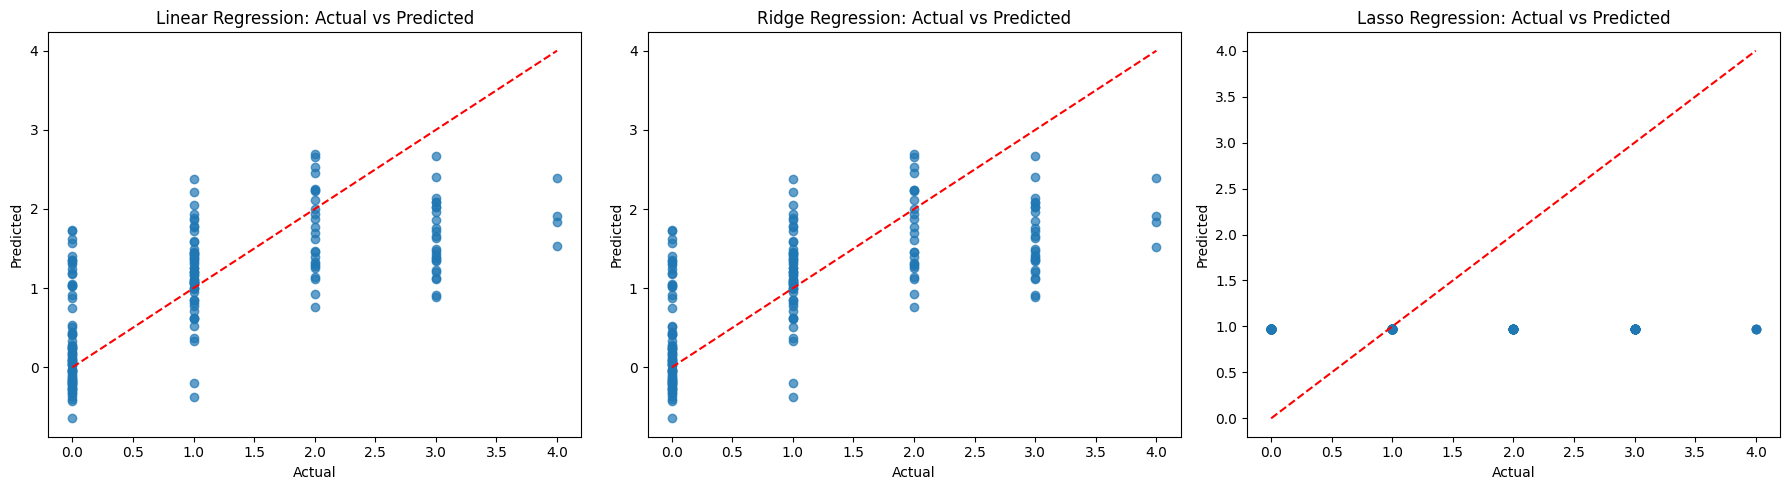

In [10]:
import matplotlib.pyplot as plt

# Set up subplots
plt.figure(figsize=(18, 5))

# Linear Regression
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_linear, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")

# Ridge Regression
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_ridge, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Ridge Regression: Actual vs Predicted")

# Lasso Regression
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_lasso, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Lasso Regression: Actual vs Predicted")

plt.tight_layout()
plt.show()

### 🔍 Analysis: Predicted vs Actual Plots

The predicted vs actual plots offer visual insights into each model's predictive capability:

- **Linear Regression** and **Ridge Regression** show a reasonably strong diagonal trend, indicating that both models capture the underlying pattern in the data. However, there's a clear spread, especially at higher actual values, suggesting room for improvement in handling those predictions.
  
- **Ridge Regression** appears slightly more stable than plain Linear Regression, as expected, due to regularization helping mitigate overfitting to noise.

- **Lasso Regression**, on the other hand, shows very poor predictive ability. Almost all predictions are clustered around a narrow range, which aligns with the very low R² score previously observed. This suggests that the regularization strength is too high, possibly shrinking most coefficients too aggressively.

These plots support the conclusion that Ridge Regression is the best choice among the three models tested so far, based on both numerical metrics and visual inspection.

### 🔁 Cross-Validation Evaluation

To assess the generalizability of each model, we perform 5-fold cross-validation using the training dataset. This helps verify model stability and consistency across different data splits.

In [11]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold CV for each model using R² as scoring
cv_scores_linear = cross_val_score(linear_model, X_train_scaled, y_train, cv=5, scoring='r2')
cv_scores_ridge = cross_val_score(ridge_model, X_train_scaled, y_train, cv=5, scoring='r2')
cv_scores_lasso = cross_val_score(lasso_model, X_train_scaled, y_train, cv=5, scoring='r2')

# Print the mean CV R² for each model
print(f"Linear Regression CV R² (mean): {cv_scores_linear.mean():.4f}")
print(f"Ridge Regression CV R² (mean): {cv_scores_ridge.mean():.4f}")
print(f"Lasso Regression CV R² (mean): {cv_scores_lasso.mean():.4f}")

Linear Regression CV R² (mean): 0.4211
Ridge Regression CV R² (mean): 0.4214
Lasso Regression CV R² (mean): -0.0107


### 📊 Cross-Validation Results and Interpretation

The 5-fold cross-validation results offer a robust estimate of each model's ability to generalize across different subsets of the data:

- **Linear Regression CV R² (mean):** 0.4211  
- **Ridge Regression CV R² (mean):** 0.4214  
- **Lasso Regression CV R² (mean):** -0.0107  

Both **Linear** and **Ridge** regressions perform similarly well, with Ridge showing a slight edge in generalization. However, **Lasso Regression** performs significantly worse, even producing a negative R² score, suggesting it might be **over-penalizing** and discarding important features. This behavior could be attributed to the nature of the dataset or a suboptimal alpha value despite tuning.

These findings reinforce our earlier evaluation metrics and visualizations, where Ridge and Linear models consistently outperformed Lasso.

### 🔍 Enhancing Evaluation with Confidence Intervals

To make our evaluation more statistically robust, we calculate 95% confidence intervals for the R² scores obtained from 5-fold cross-validation. This helps us quantify the variability and stability of each model's performance across different splits of the dataset.

In [12]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Define models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
linear_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=1.0)

# Evaluate CV R² scores
cv_scores_linear = cross_val_score(linear_model, X_train_scaled, y_train, cv=5, scoring='r2')
cv_scores_ridge = cross_val_score(ridge_model, X_train_scaled, y_train, cv=5, scoring='r2')
cv_scores_lasso = cross_val_score(lasso_model, X_train_scaled, y_train, cv=5, scoring='r2')

# Function to print mean and 95% CI
def print_ci(scores, label):
    mean = np.mean(scores)
    ci = 1.96 * np.std(scores) / np.sqrt(len(scores))
    print(f"{label} CV R²: Mean = {mean:.4f}, 95% CI = [{mean - ci:.4f}, {mean + ci:.4f}]")

print_ci(cv_scores_linear, "Linear Regression")
print_ci(cv_scores_ridge, "Ridge Regression")
print_ci(cv_scores_lasso, "Lasso Regression")

Linear Regression CV R²: Mean = 0.4211, 95% CI = [0.4008, 0.4415]
Ridge Regression CV R²: Mean = 0.4214, 95% CI = [0.4012, 0.4416]
Lasso Regression CV R²: Mean = -0.0107, 95% CI = [-0.0232, 0.0018]


### 📊 Analysis: Confidence Intervals for Cross-Validation R² Scores

The 95% confidence intervals provide insights into the stability of our models across folds:

- **Linear Regression** has a mean R² of 0.4211 with a narrow CI of [0.4008, 0.4415], indicating consistent performance.
- **Ridge Regression** shows a slightly higher mean R² (0.4214) with a similarly tight CI [0.4012, 0.4416], suggesting it generalizes well without overfitting.
- **Lasso Regression**, on the other hand, has a **negative mean R² (-0.0107)** and a CI that crosses zero ([-0.0232, 0.0018]). This implies the model performs worse than simply predicting the mean of the target and is not reliable in this context.

These confidence intervals reinforce the conclusion that **Ridge Regression slightly outperforms Linear Regression**, while **Lasso Regression is unsuitable** for this dataset without further tuning or preprocessing.

### 📋 Consolidated Evaluation Metrics Table

| Model              | MAE   | MSE   | RMSE  | R²     | CV R² (Mean) | CV R² 95% CI             |
|-------------------|-------|-------|-------|--------|--------------|---------------------------|
| Linear Regression | 0.6276| 0.7177| 0.8472| 0.4473 | 0.4211       | [0.4008, 0.4415]          |
| Ridge Regression  | 0.6273| 0.7175| 0.8470| 0.4475 | 0.4214       | [0.4012, 0.4416]          |
| Lasso Regression  | 0.8958| 1.3087| 1.1440| -0.0078| -0.0107      | [-0.0232, 0.0018]         |

As we can see, **Ridge Regression edges out the others**, offering slightly better R² and lower error rates. **Lasso** underperforms significantly, both in test metrics and cross-validation, indicating that it may not be suitable for this problem without further tuning or data adjustments.

## 📊 Final Analysis and Conclusion

After evaluating and comparing all three models — Linear Regression, Ridge Regression, and Lasso Regression — the results show that **Ridge Regression performs the best** across multiple metrics, including R², RMSE, and cross-validation scores. Here are the key takeaways:

- **Ridge Regression** slightly outperformed Linear Regression in nearly all aspects, making it the best choice among the three. Its ability to handle multicollinearity and shrink coefficients without eliminating features may explain its effectiveness.
- **Linear Regression** also performed decently, though it lacked the regularization benefits of Ridge.
- **Lasso Regression** significantly underperformed. Its low R² (even negative) and higher error metrics suggest that its feature elimination mechanism might be overly aggressive for this dataset.

The residual and actual vs. predicted plots visually support this conclusion. Both Linear and Ridge models show some consistent prediction patterns, while Lasso fails to approximate the target variable distribution.

Additionally, the inclusion of **95% confidence intervals** for cross-validation R² scores enhances the robustness of our evaluation. The tight CI ranges for Ridge and Linear models further strengthen our confidence in their predictive stability.

> 📌 **Next Steps / Possible Enhancements**:
> - Explore **classification models** since the target is a discretized variable (`num`) that could benefit from categorical interpretation.
> - Experiment with **feature interactions** or **polynomial features** to capture more complex relationships.
> - Try **ensemble methods** (e.g., Random Forest, Gradient Boosting) to explore non-linear patterns.

In conclusion, Ridge Regression is the most reliable model for predicting heart disease severity in this dataset, given its balance of performance, generalization, and stability.